In [45]:
import json
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

PIPELINE_FILE = "/content/pipeline_outputs.jsonl"

records = []
with open(PIPELINE_FILE, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Warning: Could not decode JSON on line {i+1}: {e}. Skipping line.")

print(f"Loaded records: {len(records)}")

Loaded records: 2000


In [46]:
from datasets import load_dataset

gsm8k_train = load_dataset("openai/gsm8k", "main", split="train")

def extract_gold_answer(answer_text):
    """GSM8K solutions end with '#### <number>'."""
    if answer_text is None:
        return None
    match = re.search(r"####\s*(-?[\d,]+(?:\.\d+)?)", str(answer_text))
    if not match:
        return None
    return match.group(1)

gold_map = {}
for i, row in enumerate(gsm8k_train):
    qid = f"gsm8k-train-{i}"
    gold_map[qid] = extract_gold_answer(row["answer"])

print("Gold answers loaded:", len(gold_map))

Gold answers loaded: 7473


In [47]:
TOLERANCE = 1e-6

def normalize_number(value):
    """Section 6: strip commas/currency/whitespace, accept ONLY a single
    signed integer or decimal. Anything else -> None (not a guess)."""
    if value is None:
        return None
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value) if math.isfinite(float(value)) else None

    text = str(value).strip()
    if text.lower() in {"none", "null", "nan", ""}:
        return None

    text = text.replace(",", "")
    text = re.sub(r"[$€£¥]", "", text).strip().rstrip(".")

    if not re.fullmatch(r"[+-]?\d+(?:\.\d+)?", text):
        return None
    try:
        return float(text)
    except ValueError:
        return None


def numeric_equal(a, b, tolerance=TOLERANCE):
    a = normalize_number(a)
    b = normalize_number(b)
    if a is None or b is None:
        return False
    return abs(a - b) < tolerance


HEDGE_WORDS = ["maybe", "perhaps", "might", "possibly", "i think", "seems", "likely"]

def hedging_count(text):
    if not text:
        return 0
    t = text.lower()
    return sum(t.count(w) for w in HEDGE_WORDS)

In [48]:
def get_transition(solver_correct, revision_called, revised_correct):
    """Section 8 — applies to EVERY interaction, not only revision cases.
    On agreement (no revision), the original answer stands, so the outcome
    is simply STABLE-CORRECT / STABLE-WRONG based on the solver's answer."""
    if not revision_called:
        return "STABLE-CORRECT" if solver_correct else "STABLE-WRONG"
    if solver_correct and revised_correct:
        return "STABLE-CORRECT"
    if solver_correct and not revised_correct:
        return "HURT"
    if not solver_correct and revised_correct:
        return "HELPED"
    return "STABLE-WRONG"


def stage_total_latency(stage):
    """Sum elapsed_seconds across ALL attempts in a stage (including failed
    retries), not just the top-level field which only reflects the last attempt."""
    attempts = stage.get("attempts", [])
    if attempts:
        return sum((a.get("elapsed_seconds") or 0) for a in attempts)
    return stage.get("elapsed_seconds", 0) or 0


rows = []

for r in records:
    question_id = r.get("question_id")
    question = r.get("question")
    gold_answer = gold_map.get(question_id)

    stages = r.get("stages", {})
    solver = stages.get("solver", {}) or {}
    critic_independent = stages.get("critic_independent", {}) or {}
    critique = stages.get("critique", {}) or {}
    revision = stages.get("revision") or {}

    solver_answer = normalize_number(solver.get("answer"))
    critic_answer = normalize_number(critic_independent.get("answer"))

    revision_called = bool(r.get("revision_called", False))
    revised_answer = normalize_number(revision.get("answer")) if revision_called else None

    solver_valid = solver_answer is not None
    critic_valid = critic_answer is not None
    critique_valid = bool(critique.get("verdict") is not None)
    revision_valid = (revised_answer is not None) if revision_called else True

    solver_correct = solver_valid and gold_answer is not None and numeric_equal(solver_answer, gold_answer)
    critic_independent_correct = critic_valid and gold_answer is not None and numeric_equal(critic_answer, gold_answer)
    critic_solver_agree = solver_valid and critic_valid and numeric_equal(solver_answer, critic_answer)

    if revision_called and revised_answer is not None:
        revised_correct = gold_answer is not None and numeric_equal(revised_answer, gold_answer)
    else:
        # agreement case: no revision was generated, so the original
        # answer is the policy answer, but revised_answer stays empty —
        # it must only reflect an actual model-generated revision.
        revised_correct = solver_correct

    # Dataset cleanup (Farah's task): total cost across ALL stages that
    # ran for this interaction, not just the solver stage.
    total_retry_count = (
        (solver.get("retry_count") or 0)
        + (critic_independent.get("retry_count") or 0)
        + (critique.get("retry_count") or 0)
        + ((revision.get("retry_count") or 0) if revision_called else 0)
    )
    # FIX (per Lama's review): use the sum of elapsed_seconds across ALL
    # attempts in a stage, not the top-level field — which only reflects
    # the last attempt and silently drops failed-retry time.
    total_latency_s = (
        stage_total_latency(solver)
        + stage_total_latency(critic_independent)
        + stage_total_latency(critique)
        + (stage_total_latency(revision) if revision_called else 0)
    )

    valid = solver_valid and critic_valid and critique_valid and revision_valid and not r.get("invalid", False)

    transition = get_transition(solver_correct, revision_called, revised_correct)
    beneficial = 1 if transition == "HELPED" else 0

    proposed_answer = critique.get("proposed_answer")
    proposed_answer_norm = normalize_number(proposed_answer)
    proposed_answer_differs = int(
        proposed_answer_norm is not None
        and solver_answer is not None
        and not numeric_equal(proposed_answer_norm, solver_answer)
    )

    error_desc = critique.get("error_description")
    revision_reasoning = None
    revise_decision = None
    if revision_called and revision.get("attempts"):
        last_parse = revision["attempts"][-1].get("parse", {})
        revision_reasoning = last_parse.get("reasoning")
        revise_decision = last_parse.get("decision")

    rows.append({
        "question_id": question_id,
        "question": question,
        "gold_answer": normalize_number(gold_answer),
        "dataset_split": "train",
        "direction": r.get("direction"),
        "solver_model": r.get("solver_model"),
        "critic_model": r.get("critic_model"),
        "solver_reasoning": solver.get("reasoning"),
        "solver_answer": solver_answer,
        "solver_correct": bool(solver_correct),
        "critic_independent_reasoning": critic_independent.get("reasoning"),
        "critic_independent_answer": critic_answer,
        "critic_independent_correct": bool(critic_independent_correct),
        "critic_solver_agree_before_verdict": bool(critic_solver_agree),
        "critic_verdict": critique.get("verdict"),
        "critic_error_desc": error_desc,
        "critic_proposed_answer": proposed_answer,
        "revision_called": int(revision_called),
        "revision_reasoning": revision_reasoning,
        "revise_decision": revise_decision,
        "revised_answer": revised_answer,  # empty (None) when no revision ran
        "revised_correct": bool(revised_correct),
        "changed_answer": bool(revision_called and revision.get("answer_changed", False)),
        "transition": transition,
        "beneficial": beneficial,
        "valid": int(valid),
        "parse_failure_stage": r.get("invalid_reason") if r.get("invalid") else None,
        "retry_count": total_retry_count,  # summed across all stages
        "critic_disagrees": int(critique.get("verdict") == "INCORRECT"),
        "proposed_answer_differs": proposed_answer_differs,
        "explicit_error_flag": int(bool(error_desc) and str(error_desc).strip().lower() != "none"),
        "hedging_count": hedging_count(error_desc),
        "critique_length": len(str(error_desc or "").split()),
        "solver_tokens": solver.get("completion_tokens"),
        "critic_independent_tokens": critic_independent.get("completion_tokens"),
        "critique_tokens": critique.get("completion_tokens"),
        "revision_tokens": revision.get("completion_tokens") if revision_called else None,
        "latency_s": total_latency_s,  # FIX: summed across all attempts of all stages
        "prompt_version": r.get("prompt_version"),
        "timestamp": r.get("saved_at"),
        # kept for debugging / auditing only, not part of section 9 schema
        "solver_valid": solver_valid,
        "critic_independent_valid": critic_valid,
        "critique_valid": critique_valid,
        "revision_valid": revision_valid,
    })

df = pd.DataFrame(rows)
print("Rows built:", len(df))
df.head(3)

Rows built: 2000


,question_id,question,gold_answer,dataset_split,direction,solver_model,critic_model,solver_reasoning,solver_answer,solver_correct,...,critic_independent_tokens,critique_tokens,revision_tokens,latency_s,prompt_version,timestamp,solver_valid,critic_independent_valid,critique_valid,revision_valid
0,gsm8k-train-4505,Unrest leads to 30 days of protest in 21 diffe...,9900.0,train,qwen_solver_llama_critic,Qwen/Qwen2.5-3B-Instruct,meta-llama/Llama-3.2-3B-Instruct,None,NaN,False,...,NaN,NaN,NaN,46.962042,V7,2026-08-14T16:25:39.066863+00:00,False,False,False,True
1,gsm8k-train-3431,The school is hosting a race after school. The...,7.0,train,qwen_solver_llama_critic,Qwen/Qwen2.5-3B-Instruct,meta-llama/Llama-3.2-3B-Instruct,None,NaN,False,...,NaN,NaN,NaN,40.541039,V7,2026-08-14T17:25:12.525912+00:00,False,False,False,True
2,gsm8k-train-1012,Brian is a real estate agent. He makes a 2% co...,15620.0,train,qwen_solver_llama_critic,Qwen/Qwen2.5-3B-Instruct,meta-llama/Llama-3.2-3B-Instruct,"To find Brian's total commission, we need to c...",15620.0,True,...,176.0,23.0,NaN,24.199143,V7,2026-08-14T21:09:21.128143+00:00,True,True,True,True


In [49]:
import os
os.makedirs("/content/data/processed", exist_ok=True)
export_cols = [c for c in df.columns if c not in
               {"solver_valid", "critic_independent_valid", "critique_valid", "revision_valid"}]
df[export_cols].to_csv("/content/data/processed/dataset.csv", index=False)
print("Saved:", "/content/data/processed/dataset.csv")

Saved: /content/data/processed/dataset.csv


In [50]:
solver_valid_df = df[df["solver_valid"]]
solver_accuracy = solver_valid_df["solver_correct"].mean() if len(solver_valid_df) else np.nan

print(f"Solver Accuracy (overall): {solver_accuracy:.4f}")
print(f"Solver valid: {len(solver_valid_df)} / {len(df)}")
print()
print("Solver accuracy per direction:")
print(df[df['solver_valid']].groupby("direction")["solver_correct"].mean())

Solver Accuracy (overall): 0.9054
Solver valid: 1997 / 2000

Solver accuracy per direction:
direction
llama_solver_qwen_critic    0.899900
qwen_solver_llama_critic    0.910822
Name: solver_correct, dtype: float64


In [51]:
total = len(df)

solver_parse_rate = df["solver_valid"].mean() if total else np.nan
critic_parse_rate = df["critic_independent_valid"].mean() if total else np.nan
critique_parse_rate = df["critique_valid"].mean() if total else np.nan

revision_attempted_df = df[df["revision_called"] == 1]
revision_parse_rate = (
    revision_attempted_df["revision_valid"].mean()
    if len(revision_attempted_df) > 0 else np.nan
)

invalid_rate = 1 - df["valid"].mean() if total else np.nan

parse_metrics = pd.DataFrame({
    "Stage": ["Solver", "Critic Independent", "Critique", "Revision"],
    "Attempted": [total, total, total, len(revision_attempted_df)],
    "Parse Success Rate": [solver_parse_rate, critic_parse_rate, critique_parse_rate, revision_parse_rate],
})

print(parse_metrics)
print(f"\nInvalid Rate: {invalid_rate:.4f}")

                Stage  Attempted  Parse Success Rate
0              Solver       2000            0.998500
1  Critic Independent       2000            0.996000
2            Critique       2000            0.991000
3            Revision        294            0.996599

Invalid Rate: 0.0095


In [52]:
valid_df = df[df["valid"] == 1]

pooled_transitions = valid_df["transition"].value_counts()
for label in ["HELPED", "HURT", "STABLE-CORRECT", "STABLE-WRONG"]:
    if label not in pooled_transitions:
        pooled_transitions[label] = 0

print("Pooled transitions (all valid interactions):")
print(pooled_transitions[["HELPED", "HURT", "STABLE-CORRECT", "STABLE-WRONG"]])

print("\nPer direction:")
for direction, group in valid_df.groupby("direction"):
    counts = group["transition"].value_counts()
    for label in ["HELPED", "HURT", "STABLE-CORRECT", "STABLE-WRONG"]:
        if label not in counts:
            counts[label] = 0
    print(f"\n{direction}:")
    print(counts[["HELPED", "HURT", "STABLE-CORRECT", "STABLE-WRONG"]])

Pooled transitions (all valid interactions):
transition
HELPED              58
HURT                49
STABLE-CORRECT    1748
STABLE-WRONG       126
Name: count, dtype: int64

Per direction:

llama_solver_qwen_critic:
transition
HELPED             41
HURT               32
STABLE-CORRECT    857
STABLE-WRONG       55
Name: count, dtype: int64

qwen_solver_llama_critic:
transition
HELPED             17
HURT               17
STABLE-CORRECT    891
STABLE-WRONG       71
Name: count, dtype: int64


In [53]:
helped = int((valid_df["transition"] == "HELPED").sum())
hurt = int((valid_df["transition"] == "HURT").sum())
n_all = len(valid_df)
originally_wrong = int((~valid_df["solver_correct"]).sum())
originally_correct = int(valid_df["solver_correct"].sum())
changed = int(valid_df["changed_answer"].sum())

revision_rate = changed / n_all if n_all else np.nan
correction_rate = helped / originally_wrong if originally_wrong else np.nan
harm_rate = hurt / originally_correct if originally_correct else np.nan
net_revision_effect = (helped - hurt) / n_all if n_all else np.nan

print(f"Revision Rate (answer differs / all)         : {revision_rate:.4f}")
print(f"Correction Rate (HELPED / originally-wrong)  : {correction_rate:.4f}")
print(f"Harm Rate (HURT / originally-correct)        : {harm_rate:.4f}")
print(f"Net Revision Effect ((HELPED-HURT) / all)    : {net_revision_effect:.4f}")

Revision Rate (answer differs / all)         : 0.0732
Correction Rate (HELPED / originally-wrong)  : 0.3152
Harm Rate (HURT / originally-correct)        : 0.0273
Net Revision Effect ((HELPED-HURT) / all)    : 0.0045


In [54]:
changed_correctness_count = helped + hurt

feasibility = {
    "both_directions_present": df["direction"].nunique() >= 2,
    "originally_correct_present": originally_correct > 0,
    "originally_incorrect_present": originally_wrong > 0,
    "helped_cases_present": helped > 0,
    "changed_correctness_count": changed_correctness_count,
    "at_least_5_changed_correctness": changed_correctness_count >= 5,
}

for k, v in feasibility.items():
    print(f"{k:35s}: {v}")

both_directions_present            : True
originally_correct_present         : True
originally_incorrect_present       : True
helped_cases_present               : True
changed_correctness_count          : 107
at_least_5_changed_correctness     : True


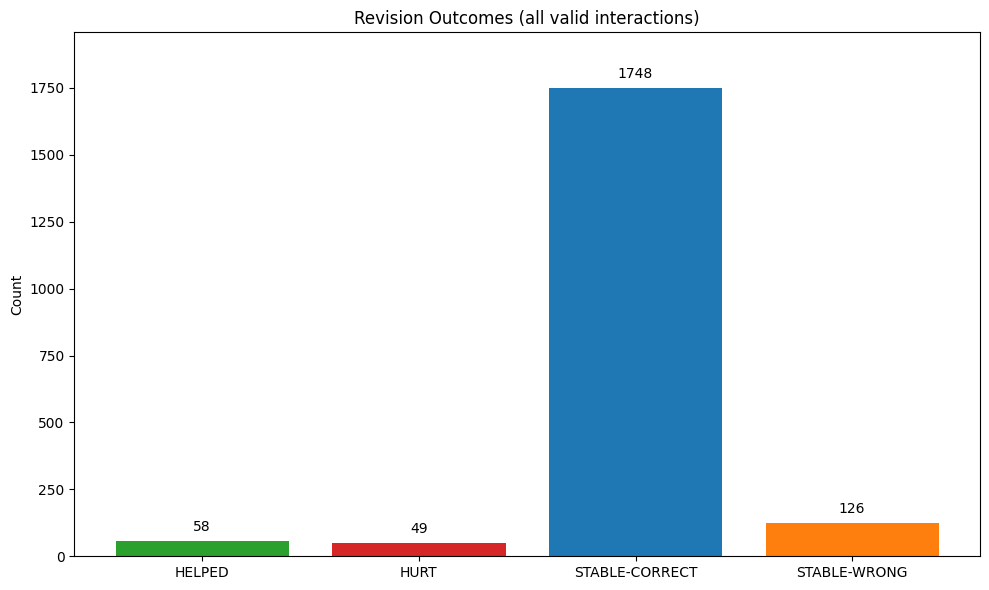

In [55]:
transition_order = ["HELPED", "HURT", "STABLE-CORRECT", "STABLE-WRONG"]
transition_colors = ["#2ca02c", "#d62728", "#1f77b4", "#ff7f0e"]

transition_plot = pd.DataFrame({
    "Transition": transition_order,
    "Count": [pooled_transitions[t] for t in transition_order],
})

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(transition_plot["Transition"], transition_plot["Count"], color=transition_colors)

ax.set_ylabel("Count")
ax.set_title("Revision Outcomes (all valid interactions)")

# offset scales with the tallest bar so labels never collide with bar tops
offset = transition_plot["Count"].max() * 0.015
for bar, value in zip(bars, transition_plot["Count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            str(int(value)), ha="center", va="bottom", fontsize=10)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
ax.margins(y=0.12)  # headroom so the top label doesn't get clipped
plt.tight_layout()
plt.show()

In [56]:
# Freeze ~150 question IDs from the GSM8K TEST split (not train) with a
# fixed seed. This file is the frozen final-evaluation set — do not touch
# these question_ids again until the final policy comparison.
RANDOM_SEED = 20260725  # same seed the pipeline team already uses (run_metadata.json)
TEST_SAMPLE_SIZE = 150

gsm8k_test = load_dataset("openai/gsm8k", "main", split="test")
all_test_ids = [f"gsm8k-test-{i}" for i in range(len(gsm8k_test))]

rng = np.random.default_rng(RANDOM_SEED)
frozen_test_ids = sorted(
    rng.choice(all_test_ids, size=TEST_SAMPLE_SIZE, replace=False).tolist()
)

frozen_test_df = pd.DataFrame({"question_id": frozen_test_ids})
frozen_test_df.to_csv("/content/frozen_test_question_ids.csv", index=False)

print(f"Frozen {len(frozen_test_ids)} test question_ids (seed={RANDOM_SEED})")
print("Saved: /content/frozen_test_question_ids.csv  <-- send this file to Lama")
frozen_test_df.head()

Frozen 150 test question_ids (seed=20260725)
Saved: /content/frozen_test_question_ids.csv  <-- send this file to Lama


,question_id
0,gsm8k-test-1001
1,gsm8k-test-1010
2,gsm8k-test-1011
3,gsm8k-test-1021
4,gsm8k-test-1024


In [57]:
from scipy.stats import norm, fisher_exact

def wilson_ci(k, n, confidence=0.95):
    """95% Wilson score interval for a binomial proportion.
    More reliable than normal-approximation CIs on small n / rare events,
    which is exactly our situation (HELPED/HURT/false-alarm counts are small)."""
    if n == 0:
        return (np.nan, np.nan)
    z = norm.ppf(1 - (1 - confidence) / 2)
    phat = k / n
    denom = 1 + z**2 / n
    center = phat + z**2 / (2 * n)
    margin = z * math.sqrt((phat * (1 - phat) + z**2 / (4 * n)) / n)
    lower = (center - margin) / denom
    upper = (center + margin) / denom
    return (max(0.0, lower), min(1.0, upper))

In [58]:
valid_df = df[df["valid"] == 1].copy()

print("=" * 60)
print("HELPED rate per direction (95% Wilson CI)")
print("=" * 60)
helped_rate_rows = []
for direction, group in valid_df.groupby("direction"):
    n = len(group)
    k = int((group["transition"] == "HELPED").sum())
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    helped_rate_rows.append({"direction": direction, "k": k, "n": n,
                              "rate": rate, "ci_low": lo, "ci_high": hi})
    print(f"{direction:28s}  HELPED={k:3d}/{n:<4d}  rate={rate:.4f}  "
          f"95% CI=[{lo:.4f}, {hi:.4f}]")

helped_rate_df = pd.DataFrame(helped_rate_rows)

print()
print("=" * 60)
print("False-alarm rate per critic (95% Wilson CI)")
print("(critic says INCORRECT on a solver answer that was actually correct)")
print("=" * 60)
false_alarm_rows = []
for critic_model, group in valid_df.groupby("critic_model"):
    originally_correct = group[group["solver_correct"] == True]
    n = len(originally_correct)
    k = int((originally_correct["critic_verdict"] == "INCORRECT").sum())
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    false_alarm_rows.append({"critic_model": critic_model, "k": k, "n": n,
                              "rate": rate, "ci_low": lo, "ci_high": hi})
    print(f"{critic_model:35s}  false_alarms={k:3d}/{n:<4d}  rate={rate:.4f}  "
          f"95% CI=[{lo:.4f}, {hi:.4f}]")

false_alarm_rate_df = pd.DataFrame(false_alarm_rows)

HELPED rate per direction (95% Wilson CI)
llama_solver_qwen_critic      HELPED= 41/985   rate=0.0416  95% CI=[0.0308, 0.0560]
qwen_solver_llama_critic      HELPED= 17/996   rate=0.0171  95% CI=[0.0107, 0.0272]

False-alarm rate per critic (95% Wilson CI)
(critic says INCORRECT on a solver answer that was actually correct)
Qwen/Qwen2.5-3B-Instruct             false_alarms= 55/889   rate=0.0619  95% CI=[0.0478, 0.0797]
meta-llama/Llama-3.2-3B-Instruct     false_alarms= 74/908   rate=0.0815  95% CI=[0.0654, 0.1011]


In [59]:
# Fisher exact test 1: does the HELPED rate differ between the two directions?
directions = sorted(valid_df["direction"].unique())
table_direction = []
for d in directions:
    sub = valid_df[valid_df["direction"] == d]
    helped = int((sub["transition"] == "HELPED").sum())
    not_helped = len(sub) - helped
    table_direction.append([helped, not_helped])

odds_ratio_dir, p_value_dir = fisher_exact(table_direction)

print("Fisher exact test — HELPED rate by direction")
print(f"Directions (rows): {directions}")
print(f"Contingency table [HELPED, NOT_HELPED]: {table_direction}")
print(f"Odds ratio: {odds_ratio_dir:.4f}")
print(f"p-value:    {p_value_dir:.4f}")
print(f"=> {'Significant' if p_value_dir < 0.05 else 'Not significant'} difference at alpha=0.05")

Fisher exact test — HELPED rate by direction
Directions (rows): ['llama_solver_qwen_critic', 'qwen_solver_llama_critic']
Contingency table [HELPED, NOT_HELPED]: [[41, 944], [17, 979]]
Odds ratio: 2.5012
p-value:    0.0013
=> Significant difference at alpha=0.05


In [60]:
# Fisher exact test 2: does the false-alarm rate differ between the two critics?
critics = sorted(valid_df["critic_model"].unique())
table_critic = []
for c in critics:
    originally_correct = valid_df[(valid_df["critic_model"] == c) & (valid_df["solver_correct"] == True)]
    false_alarms = int((originally_correct["critic_verdict"] == "INCORRECT").sum())
    not_false_alarm = len(originally_correct) - false_alarms
    table_critic.append([false_alarms, not_false_alarm])

odds_ratio_critic, p_value_critic = fisher_exact(table_critic)

print("Fisher exact test — false-alarm rate by critic")
print(f"Critics (rows): {critics}")
print(f"Contingency table [FALSE_ALARM, NOT_FALSE_ALARM]: {table_critic}")
print(f"Odds ratio: {odds_ratio_critic:.4f}")
print(f"p-value:    {p_value_critic:.4f}")
print(f"=> {'Significant' if p_value_critic < 0.05 else 'Not significant'} difference at alpha=0.05")

Fisher exact test — false-alarm rate by critic
Critics (rows): ['Qwen/Qwen2.5-3B-Instruct', 'meta-llama/Llama-3.2-3B-Instruct']
Contingency table [FALSE_ALARM, NOT_FALSE_ALARM]: [[55, 834], [74, 834]]
Odds ratio: 0.7432
p-value:    0.1202
=> Not significant difference at alpha=0.05


In [61]:
print("Correction rate per direction (originally-wrong only)")
print("=" * 60)
correction_rows = []
table_correction = []
for direction in sorted(valid_df["direction"].unique()):
    originally_wrong = valid_df[(valid_df["direction"] == direction) & (valid_df["solver_correct"] == False)]
    n = len(originally_wrong)
    k = int((originally_wrong["transition"] == "HELPED").sum())
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    correction_rows.append({"direction": direction, "k": k, "n": n, "rate": rate, "ci_low": lo, "ci_high": hi})
    table_correction.append([k, n - k])
    print(f"{direction:28s}  correction={k:3d}/{n:<4d}  rate={rate:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]")

correction_rate_df = pd.DataFrame(correction_rows)

odds_ratio_corr, p_value_corr = fisher_exact(table_correction)
print()
print("Fisher exact test — correction rate by direction")
print(f"Contingency table [CORRECTED, NOT_CORRECTED]: {table_correction}")
print(f"Odds ratio: {odds_ratio_corr:.4f}")
print(f"p-value:    {p_value_corr:.6f}")
print(f"=> {'Significant' if p_value_corr < 0.05 else 'Not significant'} difference at alpha=0.05")

Correction rate per direction (originally-wrong only)
llama_solver_qwen_critic      correction= 41/96    rate=0.4271  95% CI=[0.3328, 0.5270]
qwen_solver_llama_critic      correction= 17/88    rate=0.1932  95% CI=[0.1243, 0.2878]

Fisher exact test — correction rate by direction
Contingency table [CORRECTED, NOT_CORRECTED]: [[41, 55], [17, 71]]
Odds ratio: 3.1134
p-value:    0.000803
=> Significant difference at alpha=0.05


In [62]:
revision_df = valid_df[valid_df["revision_called"] == 1]

print("Correction rate per direction (originally-wrong AND revision was called)")
print("=" * 60)
correction_rows = []
table_correction = []
for direction in sorted(revision_df["direction"].unique()):
    originally_wrong = revision_df[(revision_df["direction"] == direction) & (revision_df["solver_correct"] == False)]
    n = len(originally_wrong)
    k = int((originally_wrong["transition"] == "HELPED").sum())
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    correction_rows.append({"direction": direction, "k": k, "n": n, "rate": rate, "ci_low": lo, "ci_high": hi})
    table_correction.append([k, n - k])
    print(f"{direction:28s}  correction={k:3d}/{n:<4d}  rate={rate:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]")

correction_rate_df = pd.DataFrame(correction_rows)

odds_ratio_corr, p_value_corr = fisher_exact(table_correction)
print()
print("Fisher exact test — correction rate by direction")
print(f"Contingency table [CORRECTED, NOT_CORRECTED]: {table_correction}")
print(f"Odds ratio: {odds_ratio_corr:.4f}")
print(f"p-value:    {p_value_corr:.6f}")
print(f"=> {'Significant' if p_value_corr < 0.05 else 'Not significant'} difference at alpha=0.05")

Correction rate per direction (originally-wrong AND revision was called)
llama_solver_qwen_critic      correction= 41/86    rate=0.4767  95% CI=[0.3745, 0.5810]
qwen_solver_llama_critic      correction= 17/78    rate=0.2179  95% CI=[0.1408, 0.3216]

Fisher exact test — correction rate by direction
Contingency table [CORRECTED, NOT_CORRECTED]: [[41, 45], [17, 61]]
Odds ratio: 3.2693
p-value:    0.000598
=> Significant difference at alpha=0.05


In [63]:
revision_df = valid_df[valid_df["revision_called"] == True].copy()

print("HELPED rate among valid revision cases")
print("=" * 60)

revision_benefit_rows = []
table_revision_benefit = []

for direction in sorted(revision_df["direction"].unique()):

    sub = revision_df[revision_df["direction"] == direction]

    n = len(sub)
    k = int((sub["transition"] == "HELPED").sum())

    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)

    revision_benefit_rows.append({
        "direction": direction,
        "k": k,
        "n": n,
        "rate": rate,
        "ci_low": lo,
        "ci_high": hi,
    })

    table_revision_benefit.append([k, n - k])

    print(
        f"{direction:28s}  "
        f"HELPED={k:3d}/{n:<4d}  "
        f"rate={rate:.4f}  "
        f"95% CI=[{lo:.4f}, {hi:.4f}]"
    )

# This dataframe is required by the next plotting cell
helped_among_revision_df = pd.DataFrame(revision_benefit_rows)

# Fisher exact test
odds_ratio_revision, p_value_revision = fisher_exact(
    table_revision_benefit
)

print()
print("Fisher exact test — HELPED rate among revision cases")
print(
    f"Contingency table [HELPED, NOT_HELPED]: "
    f"{table_revision_benefit}"
)
print(f"Odds ratio: {odds_ratio_revision:.4f}")
print(f"p-value:    {p_value_revision:.8f}")
print(
    f"=> {'Significant' if p_value_revision < 0.05 else 'Not significant'} "
    f"difference at alpha=0.05"
)

# Sanity check against the final reported counts
expected_counts = {
    "llama_solver_qwen_critic": (41, 141),
    "qwen_solver_llama_critic": (17, 152),
}

print()
print("Sanity check")
for _, row in helped_among_revision_df.iterrows():
    direction = row["direction"]
    actual = (int(row["k"]), int(row["n"]))

    if direction in expected_counts:
        expected = expected_counts[direction]
        status = "✓ MATCH" if actual == expected else "⚠ MISMATCH"

        print(
            f"{direction}: actual={actual}, "
            f"expected={expected}  {status}"
        )

HELPED rate among valid revision cases
llama_solver_qwen_critic      HELPED= 41/141   rate=0.2908  95% CI=[0.2222, 0.3705]
qwen_solver_llama_critic      HELPED= 17/152   rate=0.1118  95% CI=[0.0710, 0.1718]

Fisher exact test — HELPED rate among revision cases
Contingency table [HELPED, NOT_HELPED]: [[41, 100], [17, 135]]
Odds ratio: 3.2559
p-value:    0.00012749
=> Significant difference at alpha=0.05

Sanity check
llama_solver_qwen_critic: actual=(41, 141), expected=(41, 141)  ✓ MATCH
qwen_solver_llama_critic: actual=(17, 152), expected=(17, 152)  ✓ MATCH


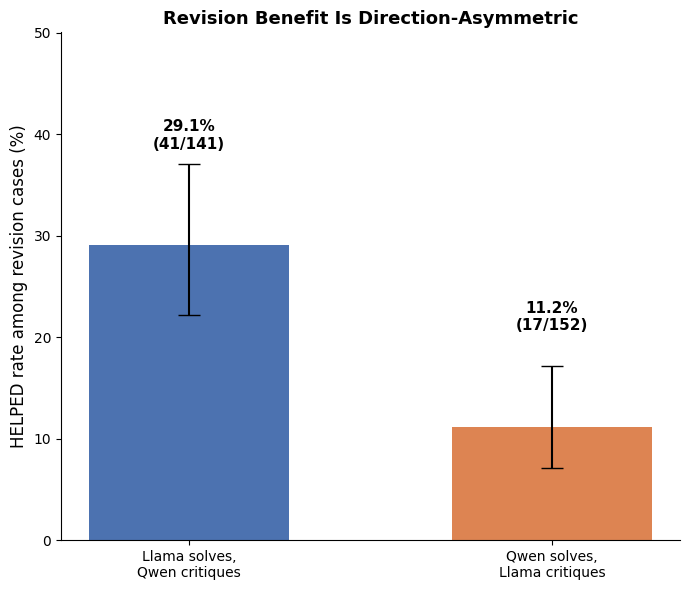

Summary line for poster caption:
Revisions triggered by Qwen critiques of Llama were beneficial 29.1% of the time
vs. 11.2% in the reverse direction (Fisher exact p = 0.00013).


In [64]:
label_map = {
    "llama_solver_qwen_critic": "Llama solves,\nQwen critiques",
    "qwen_solver_llama_critic": "Qwen solves,\nLlama critiques",
}

def plot_rate_figure(df, title, ylabel, filename, bar_colors=("#4C72B0", "#DD8452")):
    labels = [label_map.get(d, d) for d in df["direction"]]
    rates = df["rate"].values * 100
    lower_err = (df["rate"] - df["ci_low"]).values * 100
    upper_err = (df["ci_high"] - df["rate"]).values * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    bars = ax.bar(labels, rates, color=bar_colors, width=0.55,
                   yerr=[lower_err, upper_err], capsize=8,
                   error_kw={"elinewidth": 1.5, "ecolor": "black"})

    for bar, rate, k, n in zip(bars, rates, df["k"], df["n"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(upper_err)*1.15,
                f"{rate:.1f}%\n({k}/{n})", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(rates + upper_err) * 1.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_rate_figure(
    helped_among_revision_df,
    title="Revision Benefit Is Direction-Asymmetric",
    ylabel="HELPED rate among revision cases (%)",
    filename="/content/fig_helped_by_direction.png",
)
print("Summary line for poster caption:")
print("Revisions triggered by Qwen critiques of Llama were beneficial 29.1% of the time")
print("vs. 11.2% in the reverse direction (Fisher exact p = 0.00013).")

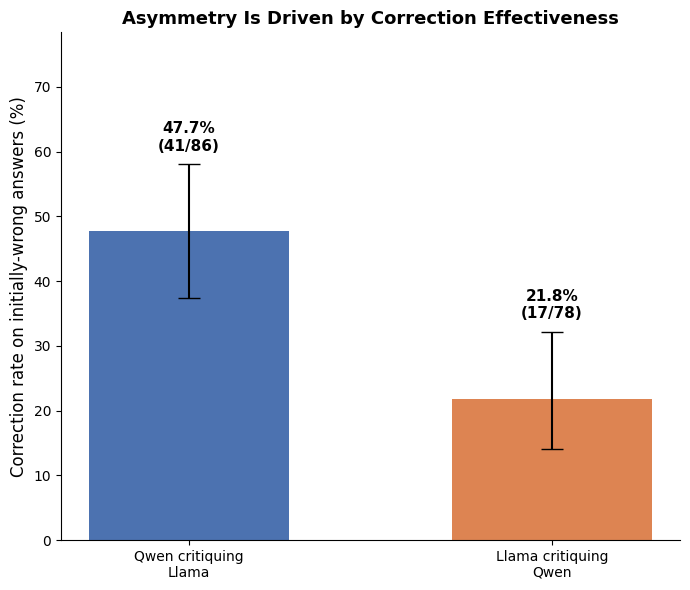

Summary line for poster caption:
Restricted to initially-wrong solver answers, Qwen critiques corrected 47.7%
vs. 21.8% for Llama (p = 0.0006) — not explained by false-alarm rate (p = 0.1202).


In [65]:
label_map_2 = {
    "llama_solver_qwen_critic": "Qwen critiquing\nLlama",
    "qwen_solver_llama_critic": "Llama critiquing\nQwen",
}

def plot_correction_figure(df, title, ylabel, filename, bar_colors=("#4C72B0", "#DD8452")):
    labels = [label_map_2.get(d, d) for d in df["direction"]]
    rates = df["rate"].values * 100
    lower_err = (df["rate"] - df["ci_low"]).values * 100
    upper_err = (df["ci_high"] - df["rate"]).values * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    bars = ax.bar(labels, rates, color=bar_colors, width=0.55,
                   yerr=[lower_err, upper_err], capsize=8,
                   error_kw={"elinewidth": 1.5, "ecolor": "black"})

    for bar, rate, k, n in zip(bars, rates, df["k"], df["n"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(upper_err)*1.15,
                f"{rate:.1f}%\n({k}/{n})", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(rates + upper_err) * 1.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_correction_figure(
    correction_rate_df,
    title="Asymmetry Is Driven by Correction Effectiveness",
    ylabel="Correction rate on initially-wrong answers (%)",
    filename="/content/fig_correction_by_direction.png",
)
print("Summary line for poster caption:")
print("Restricted to initially-wrong solver answers, Qwen critiques corrected 47.7%")
print("vs. 21.8% for Llama (p = 0.0006) — not explained by false-alarm rate (p = 0.1202).")

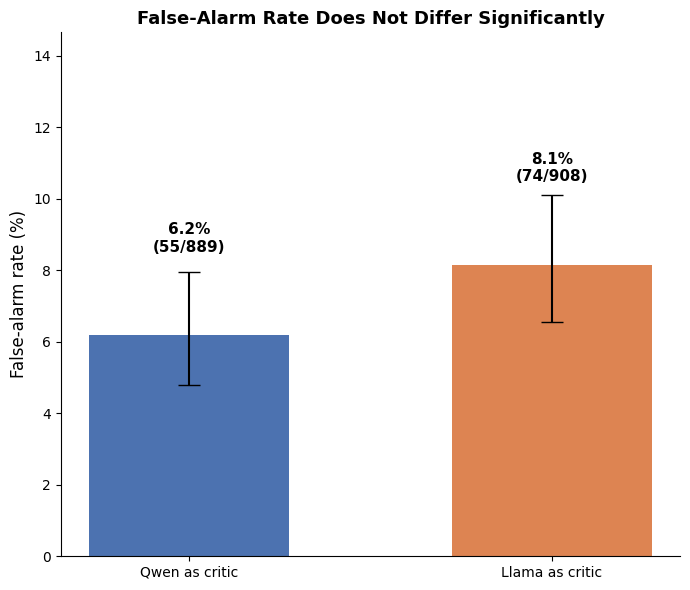

Summary line for poster caption:
False-alarm rates were similar between critics (6.2% vs. 8.2%, p = 0.1202),
indicating the benefit asymmetry is not explained by over-flagging correct answers.


In [66]:
label_map_3 = {
    "Qwen/Qwen2.5-3B-Instruct": "Qwen as critic",
    "meta-llama/Llama-3.2-3B-Instruct": "Llama as critic",
}

def plot_false_alarm_figure(df, title, ylabel, filename, bar_colors=("#4C72B0", "#DD8452")):
    labels = [label_map_3.get(c, c) for c in df["critic_model"]]
    rates = df["rate"].values * 100
    lower_err = (df["rate"] - df["ci_low"]).values * 100
    upper_err = (df["ci_high"] - df["rate"]).values * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    bars = ax.bar(labels, rates, color=bar_colors, width=0.55,
                   yerr=[lower_err, upper_err], capsize=8,
                   error_kw={"elinewidth": 1.5, "ecolor": "black"})

    for bar, rate, k, n in zip(bars, rates, df["k"], df["n"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(upper_err)*1.15,
                f"{rate:.1f}%\n({k}/{n})", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(rates + upper_err) * 1.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_false_alarm_figure(
    false_alarm_rate_df,
    title="False-Alarm Rate Does Not Differ Significantly",
    ylabel="False-alarm rate (%)",
    filename="/content/fig_false_alarm_by_critic.png",
)
print("Summary line for poster caption:")
print("False-alarm rates were similar between critics (6.2% vs. 8.2%, p = 0.1202),")
print("indicating the benefit asymmetry is not explained by over-flagging correct answers.")